# Instalação das bibliotecas


In [ ]:
!pip install utilsforecast

In [ ]:
!pip install dataframe_image

In [ ]:
!apt-get install chromium-chromedriver
!pip install dataframe_image

In [4]:
#Carrega as funções
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import dataframe_image as dfi
import nest_asyncio
from google.colab import files
from utilsforecast.losses import mae, mape,rmse,smape
from utilsforecast.evaluation import evaluate
from utilsforecast.plotting import plot_series
from google.colab import drive

## Fazer o upload do arquivo:

> avaliacao_modelos.csv



In [ ]:
# Upload dos arquivos
uploaded = files.upload()

In [17]:
# Leitura do conjunto de dados
df_metricas = pd.read_csv("avaliacao_modelos.csv")

 Métricas que foram estimadas nos scripts LSTM_final_revisado.ipynb e SARIMA.ipynb, respectivamente.

In [18]:
# Dados da tabela de métricas LSTM e SARIMA.
data = {
    'LSTM': [0.140, 0.0531, 0.167, 0.0537],
    'SARIMA':[0.49, 0.55, 0.1811, 0.1616]}

Criando um Data Frame para as métricas LSTM e SARIMA

In [19]:
# Criar o DataFrame
df = pd.DataFrame(data)

Concatenando a tabela de métricas dos modelos com as métricas LSTM e SARIMA

In [20]:
# Exibir o DataFrame
df_metricas['LSTM'] = df['LSTM']
df_metricas['Sarima'] = df['SARIMA']
df_total = df_metricas
display(df_total)

,unique_id,metric,naive,lgbm,lasso,lin_reg,ridge,knn,mlp,rf,LSTM,Sarima
0,Etanol,mae,5.3097,0.4046,1.0747,1.3756,0.5311,0.9633,0.6462,0.5636,0.1400,0.4900
1,Etanol,mape,1.8239,0.1387,0.3661,0.5044,0.1997,0.3275,0.2421,0.2050,0.0531,0.5500
2,Etanol,rmse,6.4455,0.5226,1.3435,1.4632,0.6239,1.2523,0.7457,0.6226,0.1670,0.1811
3,Etanol,smape,0.7654,0.0707,0.2362,0.1806,0.0808,0.2088,0.0960,0.0913,0.0537,0.1616


Gerando o gráfico de barras com as métricas MAE, MAPE, RMSE e sMAPE dos modelos

/tmp/ipykernel_3655/2959498622.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)
/tmp/ipykernel_3655/2959498622.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)
/tmp/ipykernel_3655/2959498622.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_cols, rotation=45)
/tmp/ipykernel_3655/2959498622.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormap

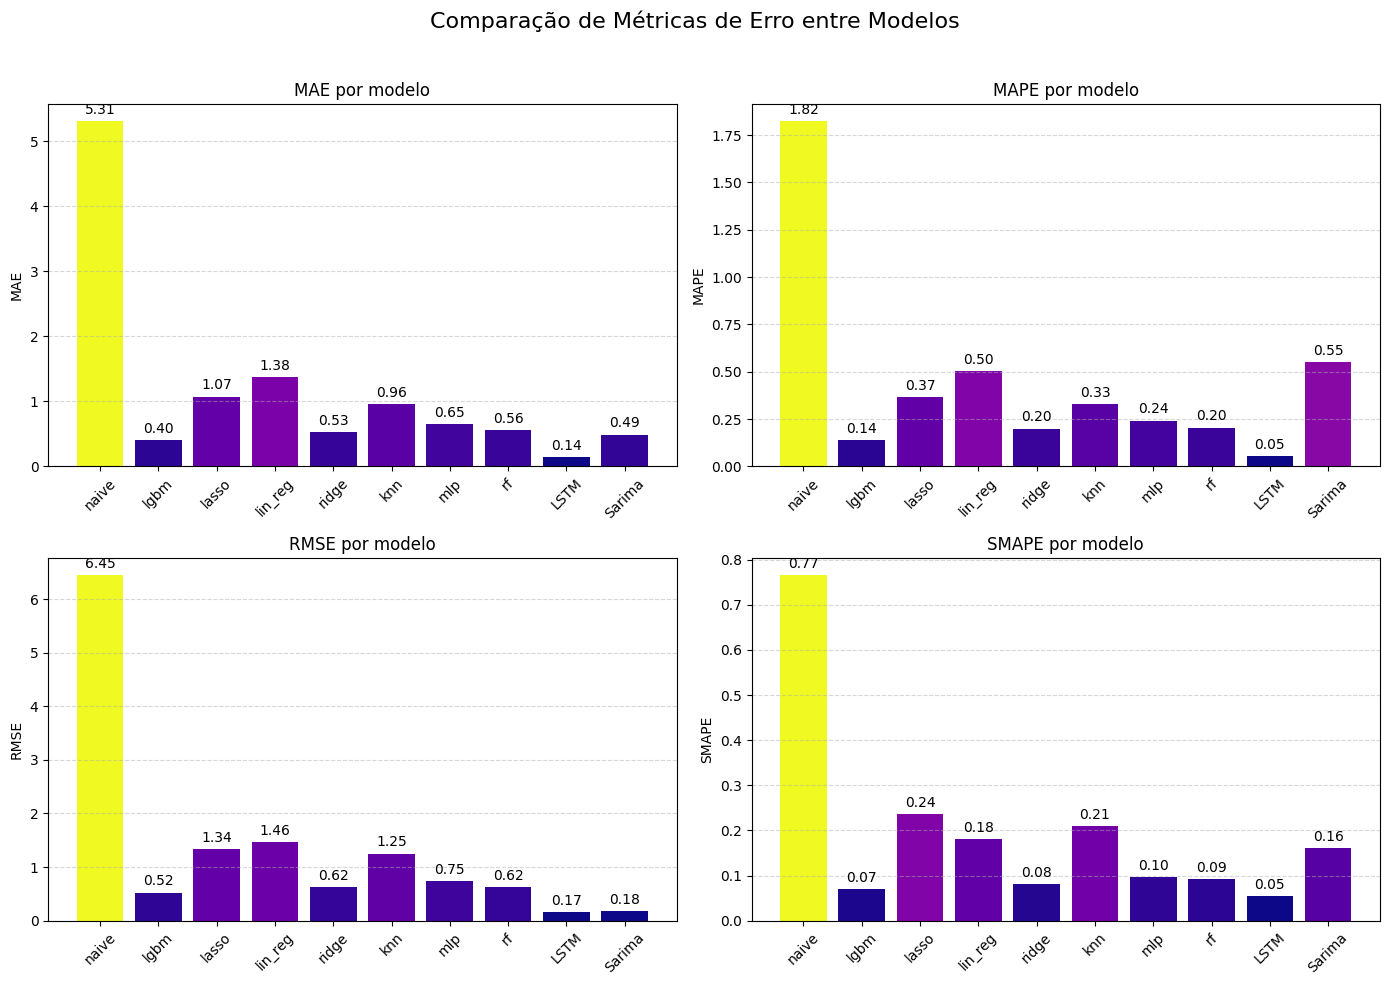

In [21]:
# Filtra só as colunas de modelos
model_cols = ['naive', 'lgbm', 'lasso', 'lin_reg', 'ridge', 'knn', 'mlp', 'rf','LSTM','Sarima']

# Define cores padrão para os modelos
def gerar_cores(valores, palette='viridis'):
    norm = plt.Normalize(min(valores), max(valores))
    cmap = cm.get_cmap(palette)
    return [cmap(norm(v)) for v in valores]

metricas = ['mae', 'mape', 'rmse', 'smape']
mae_row = df_total[df_total['metric'] == 'mae']
valores = mae_row[model_cols].values.flatten()

cores = gerar_cores(valores, palette='plasma')


# Cria uma figura com subplots por métrica
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Lista de métricas na ordem esperada
metricas = ['mae', 'mape', 'rmse', 'smape']

for i, metrica in enumerate(metricas):
    ax = axes[i]

    # Seleciona a linha da métrica
    linha = df_total[df_total['metric'] == metrica]

    # Extrai os valores dos modelos
    valores = linha[model_cols].values.flatten()

    # Creates colors based on the values of the current metric
    cores = gerar_cores(valores, palette='plasma')


    # Cria o gráfico de barras
    bars = ax.bar(model_cols, valores, color=cores)
    #ax.bar(model_cols, valores, color=cores)
    ax.set_title(f'{metrica.upper()} por modelo')
    ax.set_ylabel(metrica.upper())
    ax.set_xticklabels(model_cols, rotation=45)
    ax.bar_label(bars, fmt='%.2f', padding=3)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Comparação de Métricas de Erro entre Modelos', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Gerando uma tabela com gradiente das métricas de desempenho

In [22]:
df_total.style.background_gradient(cmap='RdYlGn_r', axis=1)

,unique_id,metric,naive,lgbm,lasso,lin_reg,ridge,knn,mlp,rf,LSTM,Sarima
0,Etanol,mae,5.309700,0.404600,1.074700,1.375600,0.531100,0.963300,0.646200,0.563600,0.140000,0.490000
1,Etanol,mape,1.823900,0.138700,0.366100,0.504400,0.199700,0.327500,0.242100,0.205000,0.053100,0.550000
2,Etanol,rmse,6.445500,0.522600,1.343500,1.463200,0.623900,1.252300,0.745700,0.622600,0.167000,0.181100
3,Etanol,smape,0.765400,0.070700,0.236200,0.180600,0.080800,0.208800,0.096000,0.091300,0.053700,0.161600


Criação de uma imagem com a tabela acima

In [23]:
nest_asyncio.apply()

styled_df = df_total.style.background_gradient(cmap='RdYlGn_r', axis=1)

dfi.export(styled_df, "tabela2.png", table_conversion='matplotlib')